In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from som_model import GeneralCLASSOM

In [2]:
MODEL_PATH = Path("../models/stress_som_model.pkl")
DATA_PATH = Path("../data/test_part_43.csv")

In [3]:
som_model = GeneralCLASSOM.load_model(MODEL_PATH)

print("SOM model loaded")
print(som_model.get_summary())

SOM model loaded
{'x': 45, 'y': 45, 'input_len': 6, 'sigma': 12, 'learning_rate': 0.3, 'decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'topology': 'rectangular', 'activation_distance': 'euclidean', 'sigma_decay_function': 'asymptotic_decay', 'random_seed': 42}


In [5]:
df_test = pd.read_csv(DATA_PATH)

print("Test data shape:", df_test.shape)

df_test.head()

Test data shape: (2300, 6)


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
0,77.957592,85.492456,105.277304,5,1.880754,0.717975
1,78.322705,84.368352,103.961155,4,1.867976,0.173581
2,78.812578,83.491660,103.169982,4,1.833611,-0.826426
3,79.640473,82.606348,87.421625,5,1.780207,-3.698196
4,80.395781,66.682589,69.672386,5,1.710697,-0.952120


In [6]:
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

X_test = df_test[FEATURE_COLS].values

print("Input matrix shape:", X_test.shape)

Input matrix shape: (2300, 6)


In [8]:
clusters = som_model.predict_cluster(X_test)

df_test["cluster"] = clusters

df_test.head(150)

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log,cluster
0,77.957592,85.492456,105.277304,5,1.880754,0.717975,0
1,78.322705,84.368352,103.961155,4,1.867976,0.173581,0
2,78.812578,83.491660,103.169982,4,1.833611,-0.826426,0
3,79.640473,82.606348,87.421625,5,1.780207,-3.698196,0
4,80.395781,66.682589,69.672386,5,1.710697,-0.952120,0
...,...,...,...,...,...,...,...
145,76.035995,52.659051,63.105938,1,1.491907,-2.876176,1
146,75.618125,54.630913,61.937648,1,1.541974,-3.283678,1
147,75.461225,54.589379,61.184536,1,1.589338,-2.458816,1
148,75.423933,54.737855,61.697171,2,1.633896,-1.925663,0


In [10]:
df_test.describe()

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log,cluster
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,71.407603,63.776070,54.775004,1.336957,4.224357,-2.163153,0.793043
std,3.776480,15.027745,12.346283,0.979978,1.355312,1.180268,0.405212
min,63.827463,32.320403,27.460734,0.000000,-5.000000,-5.000000,0.000000
25%,69.114946,51.493180,46.079286,1.000000,3.501578,-2.855690,1.000000
50%,71.236641,64.547608,53.172057,1.000000,4.600850,-2.020696,1.000000
75%,72.862080,75.359733,63.378361,2.000000,5.137204,-1.337007,1.000000
max,84.249358,103.536352,105.277304,5.000000,5.498014,0.875864,1.000000


In [11]:
df_test["state"] = df_test["cluster"].map(som_model.cluster_to_state)

In [12]:
df_test["state"].value_counts(normalize=True)
df_test["stress_level"] = df_test["cluster"].map(som_model.cluster_to_label)

In [13]:
df_test["cluster"].value_counts()

cluster
1    1824
0     476
Name: count, dtype: int64

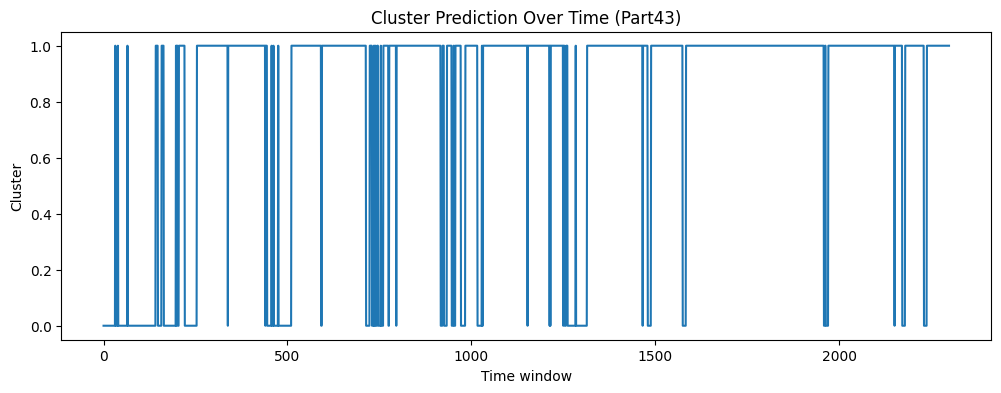

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_test["cluster"])
plt.title("Cluster Prediction Over Time (Part43)")
plt.xlabel("Time window")
plt.ylabel("Cluster")
plt.show()

In [15]:
print(np.unique(som_model.kmeans.labels_))


[0 1 2]


In [16]:
df_test.groupby("cluster")[FEATURE_COLS].mean()

,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
cluster,,,,,,
0,74.624242,71.298125,63.054962,2.651261,2.804480,-1.834189
1,70.568173,61.813078,52.614225,0.993969,4.594895,-2.249002


In [17]:
df_test.to_csv("df_test.csv", index=False)